<a href="https://colab.research.google.com/github/mochamadx5/PCVK26_11_MochamadReza/blob/main/P6_Praktikum_11_Mochamad_Reza_Firdaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
NAMA = 'Mochamad Reza Firdaus'
NIM = '244107020104'
print(NAMA, NIM)

Mochamad Reza Firdaus 244107020104


Mounted at /content/drive
Hasil Image Sharpen:


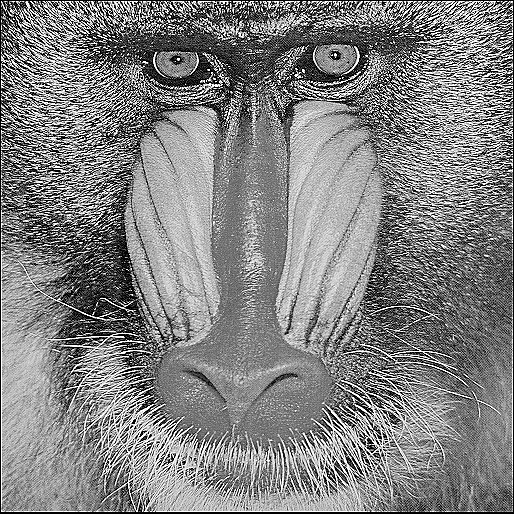

Hasil Image Emboss:


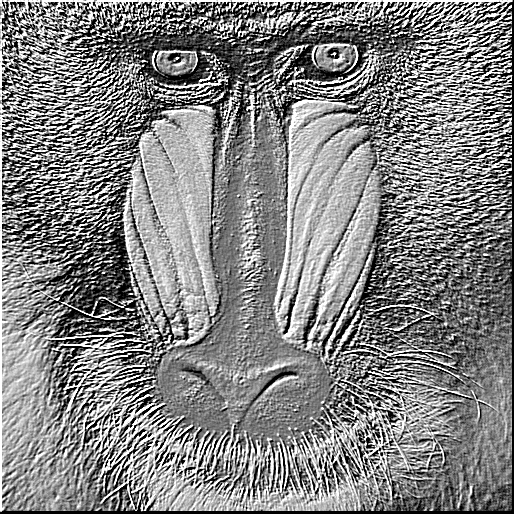

Hasil Left sobel edge detection:


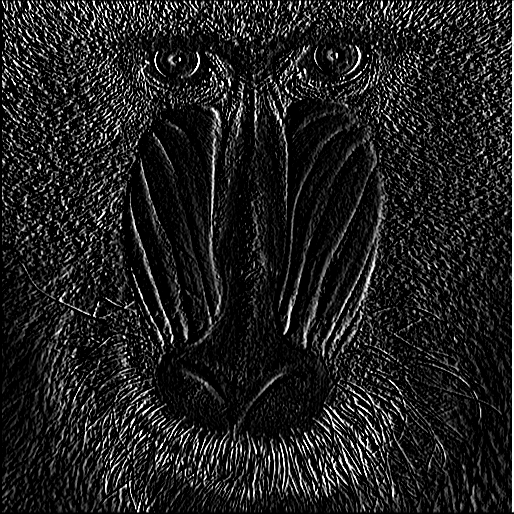

Hasil Canny Edge Detection:


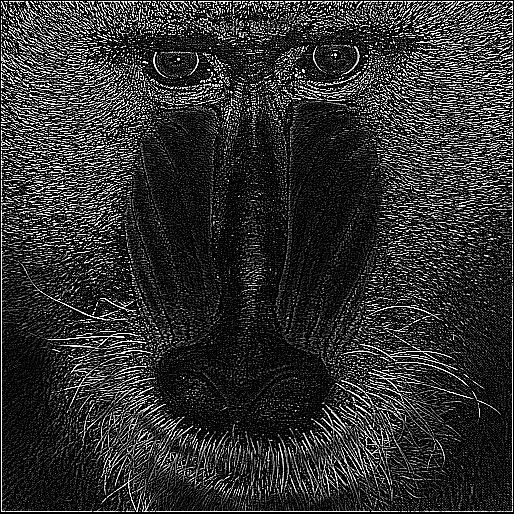

Hasil Gaussian Blur:


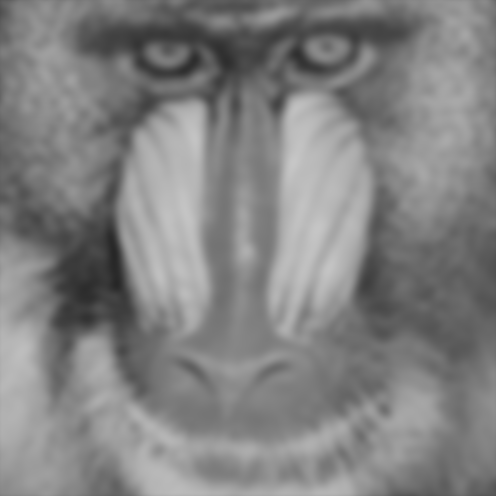

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

def convolution2d(image, kernel, stride, padding):
    # Ubah tipe data gambar ke float32 untuk menghindari overflow/underflow
    img_float = image.astype(np.float32)

    # Terapkan zero-padding di sekeliling gambar
    padded_image = np.pad(img_float, padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Hitung ukuran dimensi output
    out_h = (img_h - k_h + 2 * padding) // stride + 1
    out_w = (img_w - k_w + 2 * padding) // stride + 1

    # Inisialisasi matriks output
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # Proses konvolusi 2D
    for i in range(out_h):
        for j in range(out_w):
            start_i = i * stride
            end_i = start_i + k_h
            start_j = j * stride
            end_j = start_j + k_w

            # Ambil region of interest (ROI) sesuai ukuran kernel
            region = padded_image[start_i:end_i, start_j:end_j]

            # Operasi perkalian matriks dan penjumlahan
            output[i, j] = np.sum(region * kernel)

    # Batasi nilai piksel agar berada di rentang [0, 255] lalu ubah ke uint8
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

# Memuat gambar (Pastikan path file Anda benar dan Google Drive sudah dimount)
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Image Sharpen
kernel_sharpen = np.array([[-0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1, -0]])
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)
print("Hasil Image Sharpen:")
cv2_imshow(res_sharpen)

# Image Emboss
kernel_emboss = np.array([[-2, -1,  0],
                           [-1,  1,  1],
                           [ 0,  1,  2]])
res_emboss = convolution2d(image=img_gray, kernel=kernel_emboss, stride=1, padding=2)
print("Hasil Image Emboss:")
cv2_imshow(res_emboss)

# Image left sobel edge detection
kernel_sobel = np.array([[1,  0, -1],
                          [2,  0, -2],
                          [1,  0, -1]])
res_sobel = convolution2d(image=img_gray, kernel=kernel_sobel, stride=1, padding=2)
print("Hasil Left sobel edge detection:")
cv2_imshow(res_sobel)

# image Canny Edge Detection (Diperbaiki tanda komanya)
kernel_canny = np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]])
res_canny = convolution2d(image=img_gray, kernel=kernel_canny, stride=1, padding=2)
print("Hasil Canny Edge Detection:")
cv2_imshow(res_canny)

# Image Gaussian Blur
kernel_size = 21  # Ukuran kernel Gaussian
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
res_gaussian = convolution2d(image=img_gray, kernel=gauss_kernel, stride=1, padding=2)
print("Hasil Gaussian Blur:")
cv2_imshow(res_gaussian)

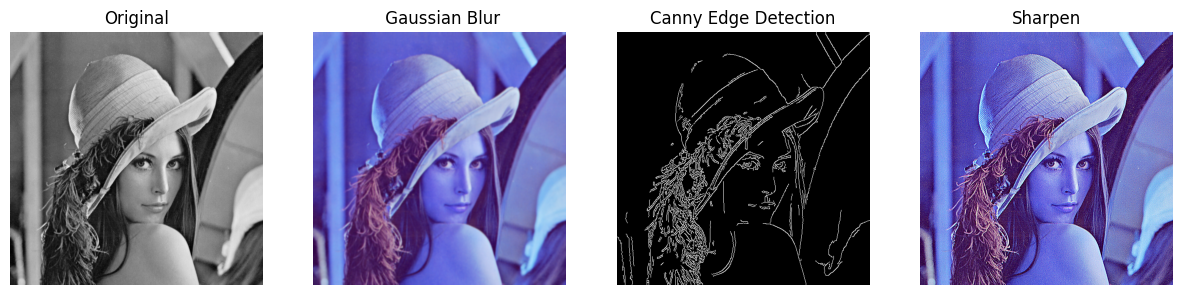

In [3]:
# FILTER LIBRARY DAN FILTER MODERN
# PERCOBAAN 1

def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
      if len(img.shape) == 2:  # grayscale
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
      else : # color
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
      plt.title(title)
      plt.axis('off')
    plt.show()
img = cv.imread('/content/drive/MyDrive/PCVK/lena.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1, 0], [-1,5,-1], [0,-1,0]])
sharpen = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img_gray, blur, edges, sharpen],
                  ['Original', ' Gaussian Blur', 'Canny Edge Detection', 'Sharpen'])

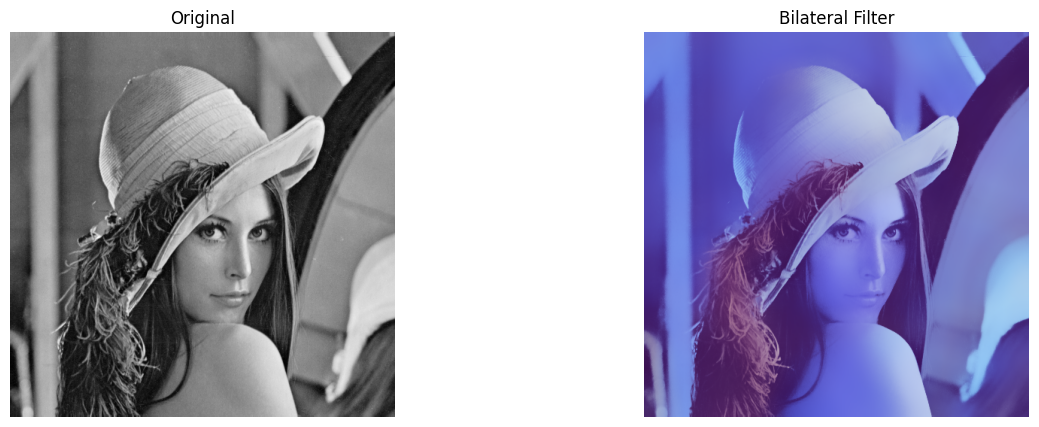

In [4]:
# PERCOBAAN 2
# filter modern dari OpenCV

# bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

#edge preserving filter
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img_gray, bilateral], ['Original', 'Bilateral Filter', 'Edge Preserving Filter'])

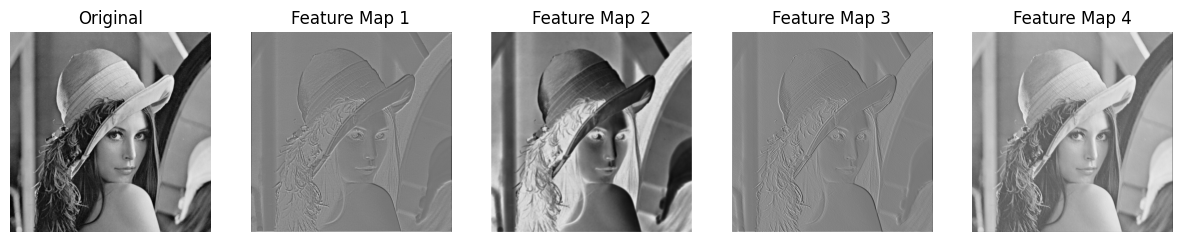

In [5]:
# PERCOBAAN 3
# Filtering pada CNN (bagian Feature Map)

import torch
import torch.nn as nn

class simpleCNN(nn.Module):
    def __init__(self):
        super(simpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)
    def forward (self, x) :
        return self.conv1(x)

model = simpleCNN()
# ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Original'] + [f'Feature Map {i+1}' for i in range(features.shape[1])])

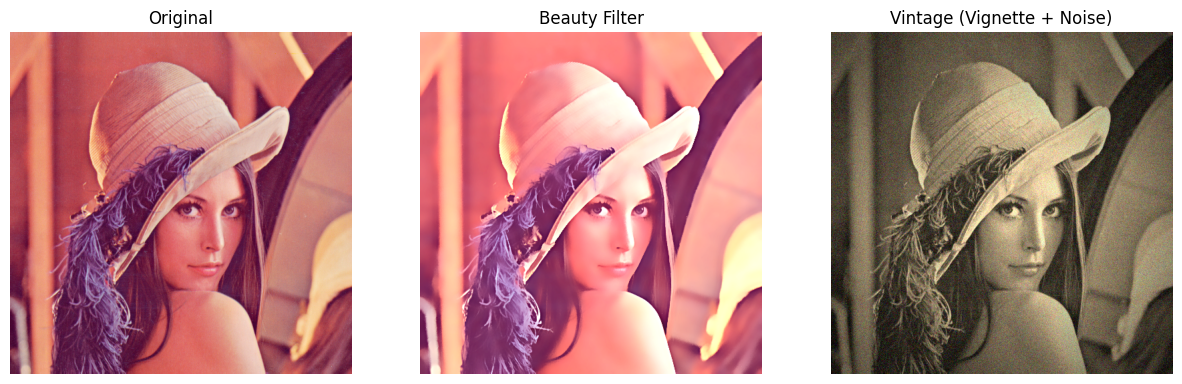

In [10]:
# PERCOBAAN 4
# 1. Beatufy Filter
# Step 1 : smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# step 2 : unsharp masking
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# step 3 : brightness & contrast
alpha = 1.2 # contrast
beta = 15 # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. old/vintage filter
#step 1 : sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# step 2 : Vignette
rows, cols = img.shape[:2]
# Membuat mask Gaussian untuk efek Vignette
kernel_x = cv.getGaussianKernel(cols, cols/2)
kernel_y = cv.getGaussianKernel(rows, rows/2)
kernel_matrix = kernel_y * kernel_x.T
mask = kernel_matrix / kernel_matrix.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = np.clip(vignette[:, :, i] * mask, 0, 255)
vignette = vignette.astype(np.uint8)

# step 3 : Noise Grain
noise = np.random.normal(0, 15, img.shape).astype(np.int16)
vintage_noisy = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Menampilkan semua hasil filter
show_side_by_side([cv.cvtColor(img, cv.COLOR_BGR2RGB),
                    cv.cvtColor(beauty, cv.COLOR_BGR2RGB),
                    cv.cvtColor(vintage_noisy, cv.COLOR_BGR2RGB)],
                   ['Original', 'Beauty Filter', 'Vintage (Vignette + Noise)'])

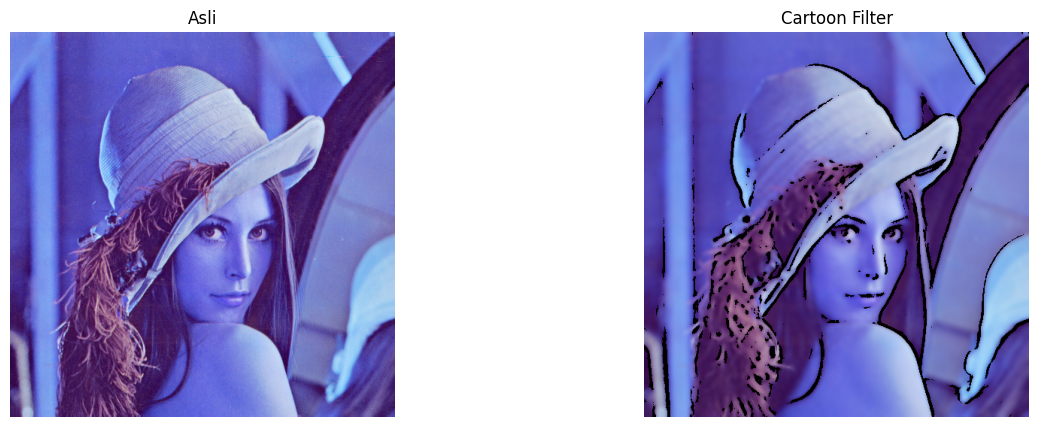

In [13]:
# PERCOBAAN 5
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                            cv.ADAPTIVE_THRESH_MEAN_C,
                            cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

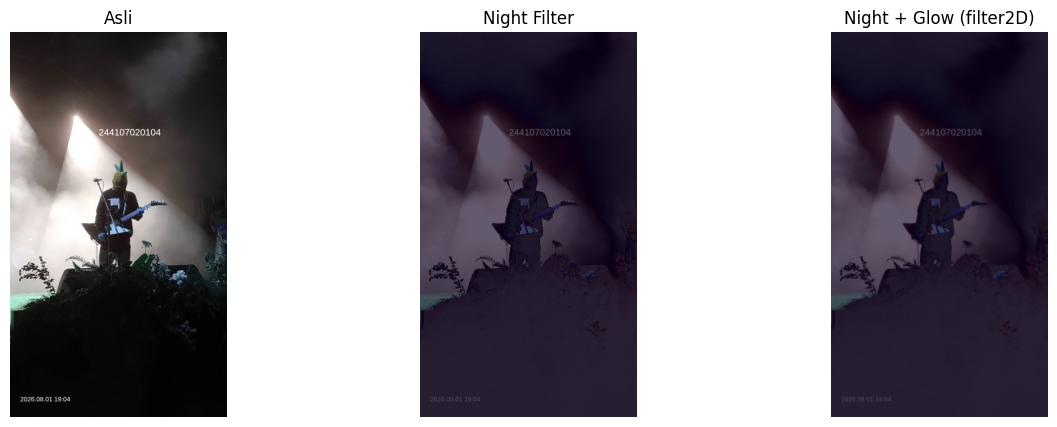

In [15]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/night1.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

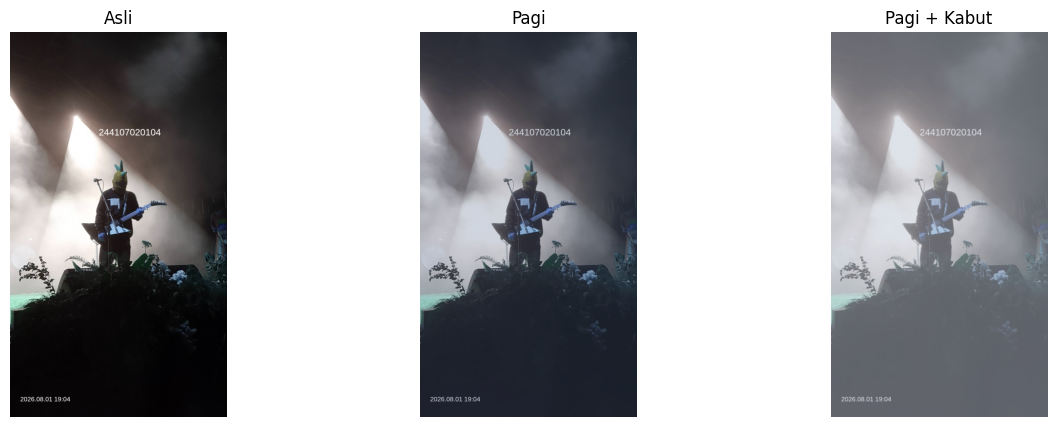

In [19]:
# PERCOBAAN 7
#Filter Suasana pagi dan Kabut
# ==========================
# Step 1: Kurangi kontras & cerahkan
# ==========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import random

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else: # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

# Memperbaiki path dengan menambahkan folder /PCVK/
img = cv.imread('/content/drive/MyDrive/PCVK/night1.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

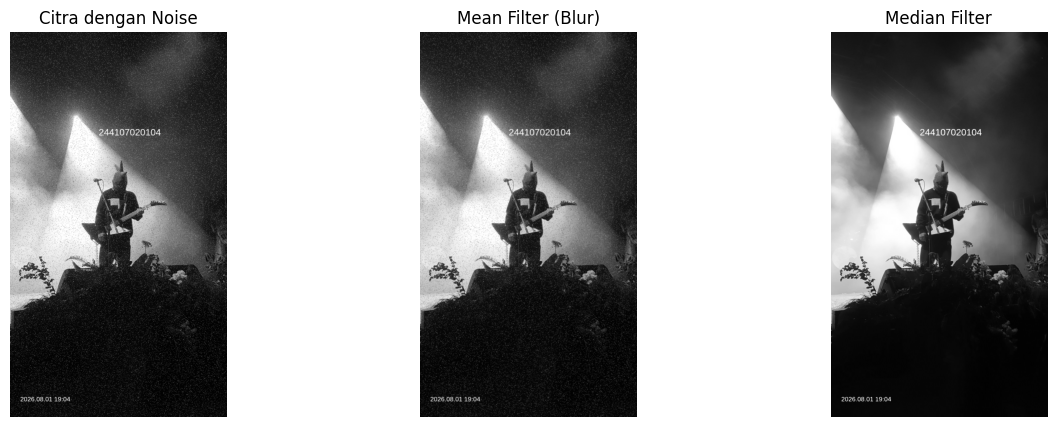

In [28]:
# 1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper"
# a. Menambahkan noise Salt and Pepper
noise_img = img_gray.copy()
prob = 0.05 # 5% noise
for i in range(noise_img.shape[0]):
    for j in range(noise_img.shape[1]):
        rdn = random.random()
        if rdn < prob/2:
            noise_img[i][j] = 0 # Pepper (Hitam)
        elif rdn < prob:
            noise_img[i][j] = 255 # Salt (Putih)

# b. Terapkan Mean Filter 3x3 dan Median Filter 3x3
mean_filter = cv.blur(noise_img, (3, 3))
median_filter = cv.medianBlur(noise_img, 3)

show_side_by_side(
    [noise_img, mean_filter, median_filter],
    ['Citra dengan Noise', 'Mean Filter (Blur)', 'Median Filter']
)

Analisis Visual:
Median Filter jauh lebih bersih dalam menghapus noise Salt and Pepper karena metode ini mengambil median dari piksel-piksel tetangganya. Salt and Pepper merupakan piksel anomali dengan nilai ekstrem (0 atau 255). Saat diurutkan untuk mencari nilai median, nilai ekstrem tersebut akan diabaikan sehingga noise hilang sempurna. Sebaliknya, Mean Filter menghitung nilai rata-rata dari seluruh piksel tetangga, termasuk nilai ekstrem noise tersebut, sehingga noise tidak benar-benar hilang melainkan menyebar dan membuat gambar terlihat buram dengan bercak-bercak samar.

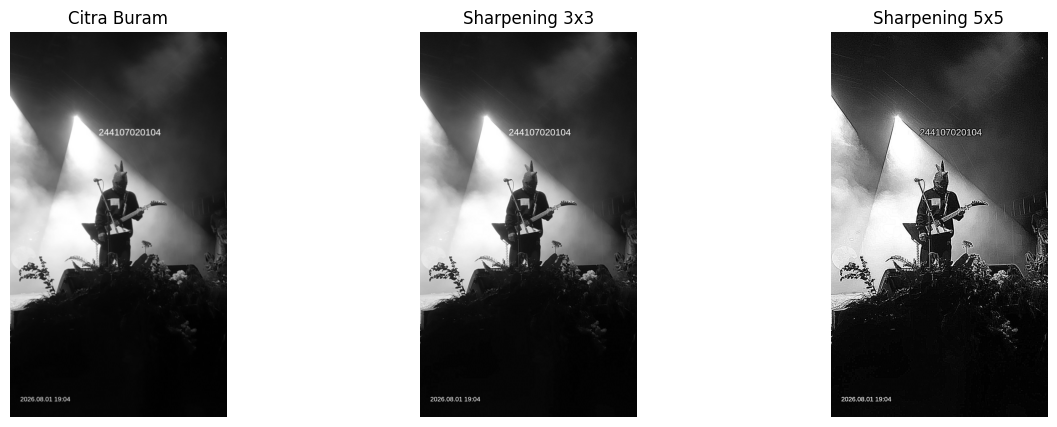

In [30]:
# 2. Tugas Evaluasi: Pemilihan Ukuran Kernel untuk Sharpening
# Simulasi citra sedikit buram terlebih dahulu
img_blurry = cv.GaussianBlur(img_gray, (5,5), 0)

# a. Buat kernel penajaman 3x3 dan 5x5
kernel_3x3 = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])

# Kernel 5x5 (Laplacian based unsharp mask)
kernel_5x5 = np.array([[-1, -1, -1, -1, -1],
                       [-1, -1, -1, -1, -1],
                       [-1, -1, 25, -1, -1],
                       [-1, -1, -1, -1, -1],
                       [-1, -1, -1, -1, -1]])

# b. Terapkan pada citra buram
sharpen_3x3 = cv.filter2D(img_blurry, -1, kernel_3x3)
sharpen_5x5 = cv.filter2D(img_blurry, -1, kernel_5x5)

show_side_by_side(
    [img_blurry, sharpen_3x3, sharpen_5x5],
    ['Citra Buram', 'Sharpening 3x3', 'Sharpening 5x5']
)

Evaluasi:
Kernel ukuran 3 x 3 adalah opsi yang paling optimal untuk digunakan sehari-hari. Pada hasil evaluasi, kernel 3x3 mampu memperjelas tepi objek dengan baik tanpa memicu terlalu banyak distorsi/noise. Sementara itu, kernel 5x5 memang menajamkan citra lebih kuat, namun terlalu agresif. Ukuran area tetangga yang lebih luas yaitu 25 piksel menyebabkan perbedaan intensitas meningkat drastis, sehingga kadar noise melonjak tajam karena efek oversharpening dan memunculkan halo effect yang kasar pada gambar.

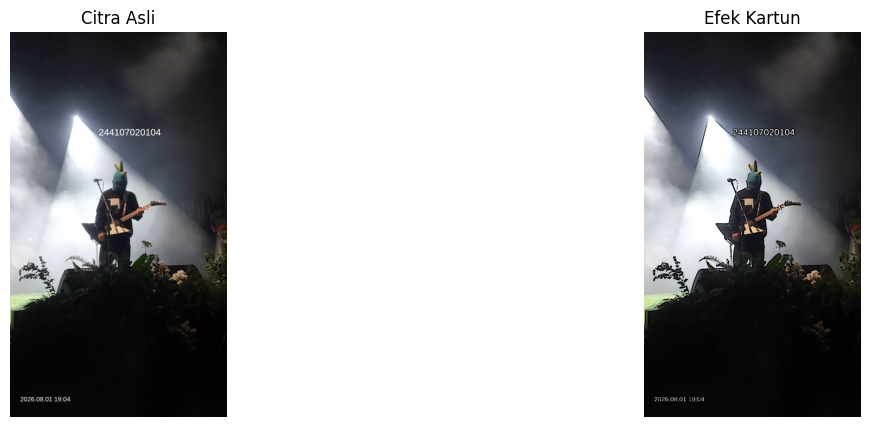

In [31]:
# 3. Tugas Kreasi: Filter Kartun Sederhana
# a. Buat fungsi kustom bernama kartun(image)
def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter agar area warna menjadi rata
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7) # Di-blur dulu agar garis tepi lebih bersih
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # 3. Penggabungan menggunakan operasi logika
    cartoon = cv.bitwise_and(color, color, mask=edges)

    return cartoon

# b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan
img_cartoon = kartun(img)

show_side_by_side(
    [img, img_cartoon],
    ['Citra Asli', 'Efek Kartun']
)